#  Étape 1 — Analyse Exploratoire des Données (EDA)

**Projet** : Sentiment Analysis — Avis d'applications marocaines/africaines

**Dataset** : 29 405 avis Google Play


**Objectif** : Comprendre la distribution, identifier les anomalies, calibrer les hyperparamètres

In [1]:
# ═══════════════════════════════════════════════════════
# MONTAGE GOOGLE DRIVE
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Chemins du projet
import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
print(" Drive monté avec succès")
print(f" Projet : {PROJECT_DIR}")

Mounted at /content/drive
 Drive monté avec succès
 Projet : /content/drive/MyDrive/Projet_Sentiment_Analysis


In [2]:
# ═══════════════════════════════════════════════════════
# INSTALLATION DES DÉPENDANCES
# ═══════════════════════════════════════════════════════
!pip install -q wordcloud langdetect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliothèques chargées")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Bibliothèques chargées


In [3]:
# ═══════════════════════════════════════════════════════
# CHARGEMENT DU DATASET
# ═══════════════════════════════════════════════════════
CSV_PATH = os.path.join(DATA_DIR, 'dataset_avis_apps.csv')

df = pd.read_csv(CSV_PATH)

print(f" Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n Colonnes : {list(df.columns)}")
print(f"\n Types :\n{df.dtypes}")
print(f"\n Valeurs manquantes :\n{df.isnull().sum()}")
print(f"\n Aperçu :")
df.head(10)

 Dataset chargé : 29405 lignes × 7 colonnes

 Colonnes : ['application', 'categorie', 'note', 'sentiment', 'avis', 'date_avis', 'likes']

 Types :
application    object
categorie      object
note            int64
sentiment      object
avis           object
date_avis      object
likes           int64
dtype: object

 Valeurs manquantes :
application    0
categorie      0
note           0
sentiment      0
avis           4
date_avis      0
likes          0
dtype: int64

 Aperçu :


,application,categorie,note,sentiment,avis,date_avis,likes
0,Attijari Mobile,Banque,1,negative,Depuis quelque mois je n'ai plus accès a l'app...,2026-06-04 14:29:16,0
1,Attijari Mobile,Banque,1,negative,توجد به أخطاء بعد التحدئثات الاخيرة,2026-06-04 01:49:11,0
2,Attijari Mobile,Banque,1,negative,location,2026-06-03 19:42:33,0
3,Attijari Mobile,Banque,1,negative,prob changer l appareil malgré qu il fonctionn...,2026-06-01 15:35:31,0
4,Attijari Mobile,Banque,1,negative,depuis la dernière mise à jour je n'arrive plu...,2026-06-01 08:22:20,0
5,Attijari Mobile,Banque,1,negative,ces deux derniers mois je n'arrive plus à me c...,2026-05-29 17:02:58,0
6,Attijari Mobile,Banque,1,negative,mauvaise,2026-05-28 11:26:31,2
7,Attijari Mobile,Banque,1,negative,vous ne voudriez pas résoudre le problème d'er...,2026-05-24 17:30:15,0
8,Attijari Mobile,Banque,1,negative,المطور للبرنامج داخل من الشرجم.. بباك صاحبي .....,2026-05-24 16:57:26,0
9,Attijari Mobile,Banque,1,negative,impeccable 👍,2026-05-21 01:10:04,0


## 1. Statistiques Générales

In [4]:
# ═══════════════════════════════════════════════════════
# STATISTIQUES GÉNÉRALES
# ═══════════════════════════════════════════════════════

COL_TEXTE     = 'avis'       # colonne contenant l'avis
COL_SENTIMENT = 'sentiment'   # colonne contenant le label
COL_NOTE      = 'note'        # colonne contenant la note 1-5
COL_APP       = 'application'         # colonne contenant le nom de l'app
COL_CATEGORIE = 'categorie'   # colonne contenant la catégorie

print("="*60)
print("STATISTIQUES GÉNÉRALES")
print("="*60)
print(f"\n Nombre total d'avis     : {len(df):,}")
print(f" Nombre d'applications   : {df[COL_APP].nunique()}")
print(f" Nombre de catégories    : {df[COL_CATEGORIE].nunique()}")
print(f" Notes min/max           : {df[COL_NOTE].min()} — {df[COL_NOTE].max()}")

# Doublons
n_doublons = df.duplicated(subset=[COL_TEXTE, COL_APP]).sum()
print(f"\n Doublons (même texte + app) : {n_doublons} ({100*n_doublons/len(df):.1f}%)")

# Textes vides ou très courts
df['longueur'] = df[COL_TEXTE].astype(str).apply(len)
df['nb_mots']  = df[COL_TEXTE].astype(str).apply(lambda x: len(x.split()))

n_vides  = (df['longueur'] < 3).sum()
n_courts = (df['nb_mots'] < 3).sum()
print(f" Textes < 3 caractères   : {n_vides}")
print(f" Textes < 3 mots         : {n_courts}")

print(f"\n Longueur moyenne (chars) : {df['longueur'].mean():.0f}")
print(f" Longueur médiane (chars) : {df['longueur'].median():.0f}")
print(f" Nombre moyen de mots    : {df['nb_mots'].mean():.1f}")

STATISTIQUES GÉNÉRALES

 Nombre total d'avis     : 29,405
 Nombre d'applications   : 11
 Nombre de catégories    : 9
 Notes min/max           : 1 — 5

 Doublons (même texte + app) : 9067 (30.8%)
 Textes < 3 caractères   : 1026
 Textes < 3 mots         : 15119

 Longueur moyenne (chars) : 44
 Longueur médiane (chars) : 15
 Nombre moyen de mots    : 7.6


## 2. Distribution des Sentiments

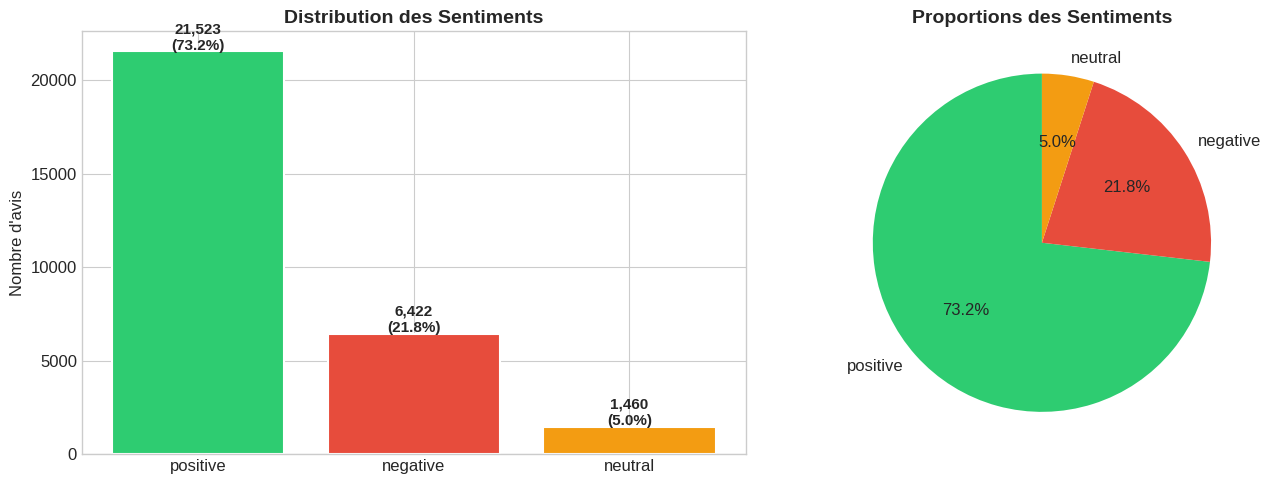


 Ratio de déséquilibre :
   positive   : 14.7x la classe minoritaire
   negative   : 4.4x la classe minoritaire
   neutral    : 1.0x la classe minoritaire


In [5]:
# ═══════════════════════════════════════════════════════
# DISTRIBUTION DES SENTIMENTS
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barplot avec comptages
sentiment_counts = df[COL_SENTIMENT].value_counts()
colors = {'positif': '#2ecc71', 'neutre': '#f39c12', 'négatif': '#e74c3c',
          'negatif': '#e74c3c', 'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
bar_colors = [colors.get(s, '#3498db') for s in sentiment_counts.index]

bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}\n({100*val/len(df):.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribution des Sentiments', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'avis')

# Graphique 2 : Camembert (pie chart)
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
           colors=bar_colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportions des Sentiments', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distribution_sentiments.png'), dpi=150, bbox_inches='tight')
plt.show()

# Ratio de déséquilibre
print("\n Ratio de déséquilibre :")
for sent in sentiment_counts.index:
    ratio = sentiment_counts[sent] / sentiment_counts.min()
    print(f"   {sent:10s} : {ratio:.1f}x la classe minoritaire")

## 3. Distribution par Application

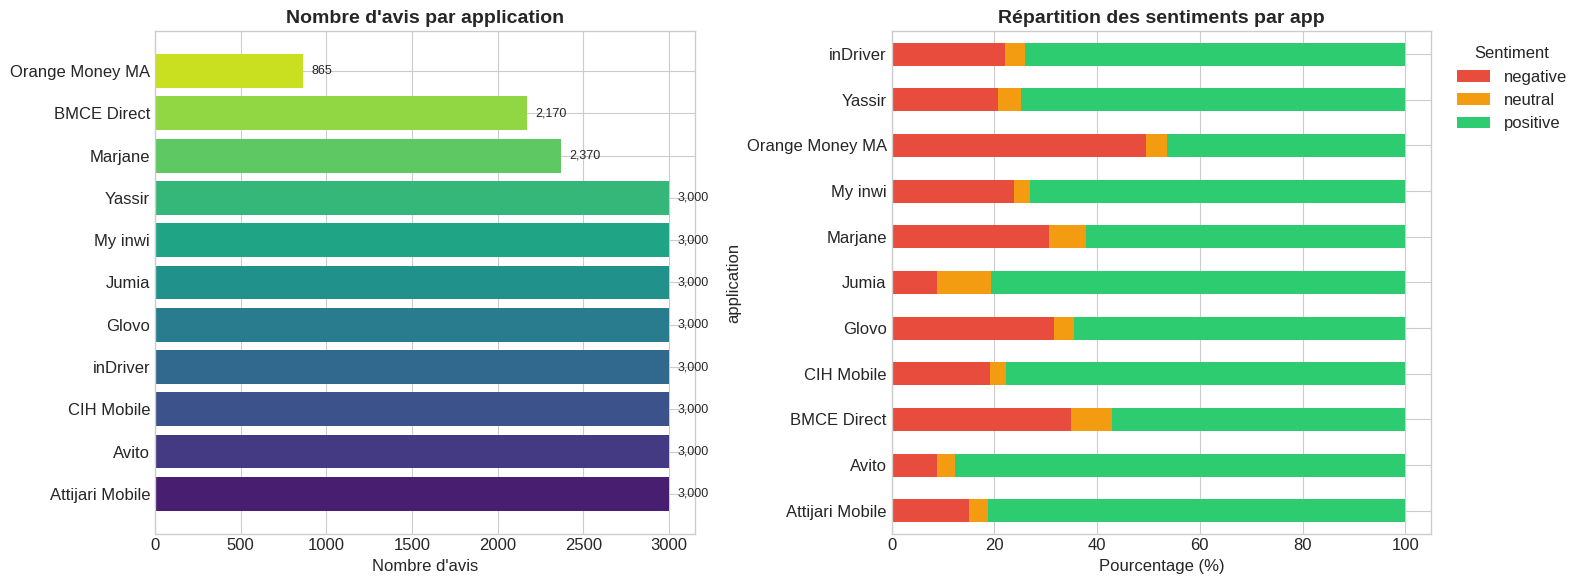

In [6]:
# ═══════════════════════════════════════════════════════
# DISTRIBUTION PAR APPLICATION
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nombre d'avis par app
app_counts = df[COL_APP].value_counts()
axes[0].barh(app_counts.index, app_counts.values, color=sns.color_palette("viridis", len(app_counts)))
axes[0].set_xlabel('Nombre d\'avis')
axes[0].set_title('Nombre d\'avis par application', fontsize=14, fontweight='bold')
for i, v in enumerate(app_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Sentiment par app (stacked bar)
cross = pd.crosstab(df[COL_APP], df[COL_SENTIMENT], normalize='index') * 100
cross.plot(kind='barh', stacked=True, ax=axes[1],
           color=[colors.get(c, '#3498db') for c in cross.columns])
axes[1].set_xlabel('Pourcentage (%)')
axes[1].set_title('Répartition des sentiments par app', fontsize=14, fontweight='bold')
axes[1].legend(title='Sentiment', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distribution_par_app.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribution par Catégorie

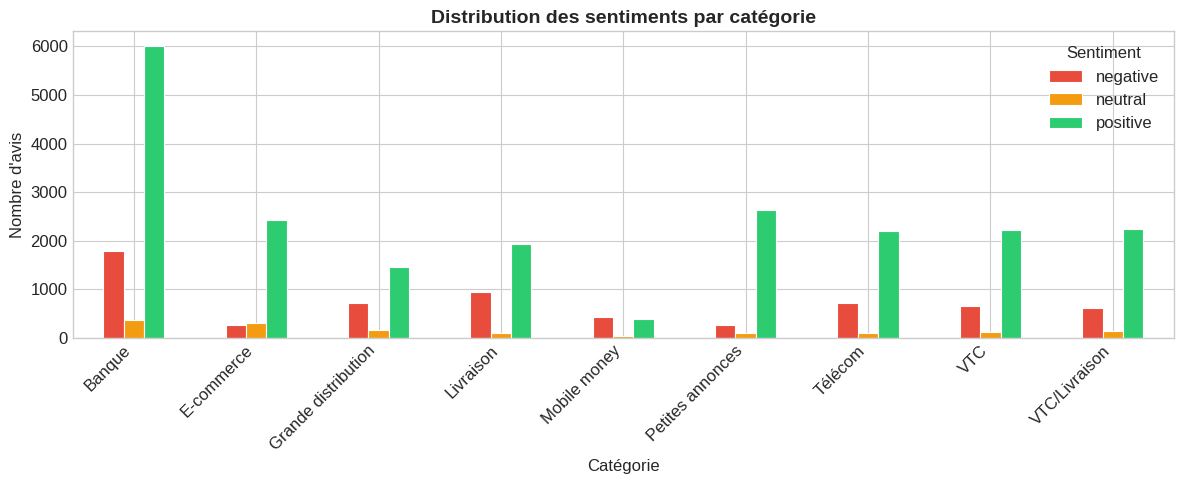

In [7]:
# ═══════════════════════════════════════════════════════
# DISTRIBUTION PAR CATÉGORIE
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

cross_cat = pd.crosstab(df[COL_CATEGORIE], df[COL_SENTIMENT])
cross_cat.plot(kind='bar', ax=ax, color=[colors.get(c, '#3498db') for c in cross_cat.columns],
               edgecolor='white', linewidth=0.8)
ax.set_title('Distribution des sentiments par catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Nombre d\'avis')
ax.legend(title='Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distribution_par_categorie.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Distribution des Notes (1-5)

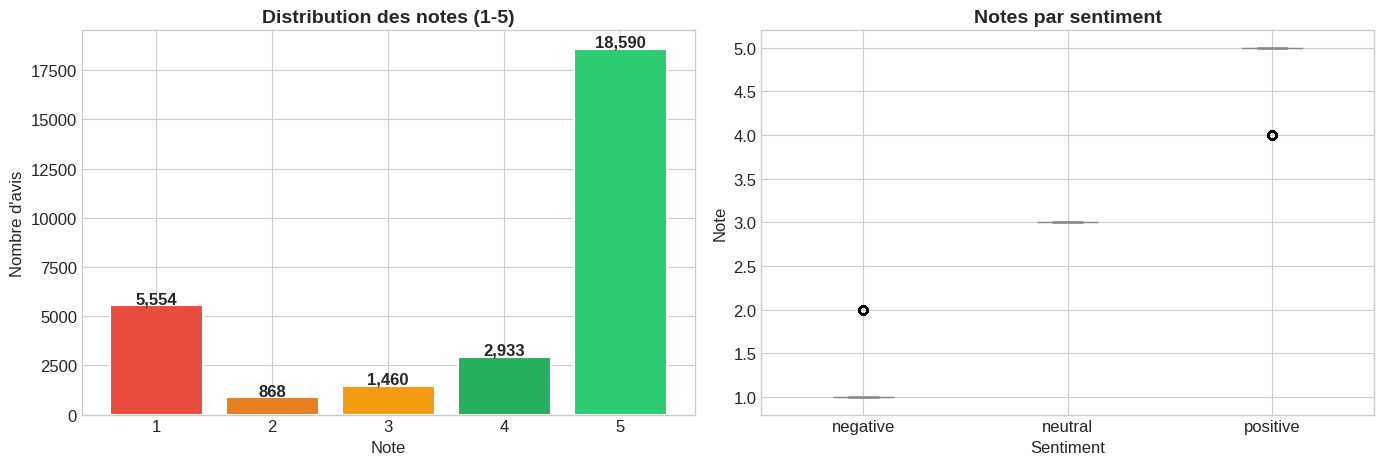

In [8]:
# ═══════════════════════════════════════════════════════
# DISTRIBUTION DES NOTES
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des notes
note_colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71']
note_counts = df[COL_NOTE].value_counts().sort_index()
axes[0].bar(note_counts.index, note_counts.values, color=note_colors, edgecolor='white', linewidth=1.5)
for i, (note, count) in enumerate(zip(note_counts.index, note_counts.values)):
    axes[0].text(note, count + 100, f'{count:,}', ha='center', fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre d\'avis')
axes[0].set_title('Distribution des notes (1-5)', fontsize=14, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Boxplot note par sentiment
df.boxplot(column=COL_NOTE, by=COL_SENTIMENT, ax=axes[1])
axes[1].set_title('Notes par sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Note')
plt.suptitle('')  # Supprimer le titre automatique

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'distribution_notes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Analyse des Longueurs de Texte

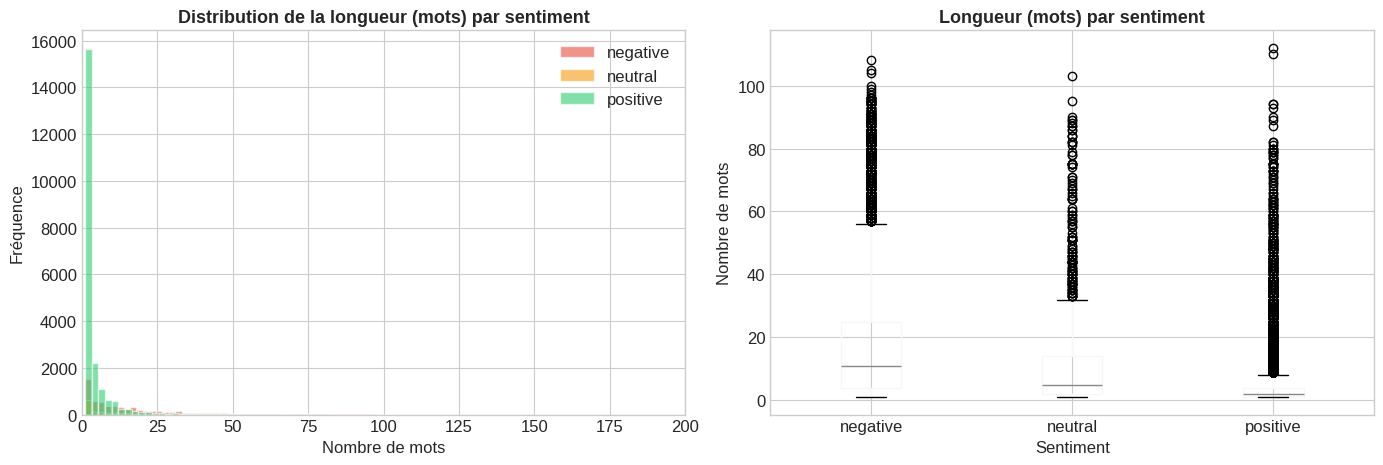


 Statistiques de longueur (mots) par sentiment :
             count  mean   std  min  25%   50%   75%    max
sentiment                                                  
negative    6422.0  18.4  20.5  1.0  4.0  11.0  25.0  108.0
neutral     1460.0  11.3  16.0  1.0  2.0   5.0  14.0  103.0
positive   21523.0   4.1   7.0  1.0  1.0   2.0   4.0  112.0

 Percentiles de longueur (mots) — pour calibrer max_len :
   P50 = 2 mots
   P75 = 7 mots
   P90 = 20 mots
   P95 = 34 mots
   P99 = 74 mots


In [9]:
# ═══════════════════════════════════════════════════════
# ANALYSE DES LONGUEURS
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des longueurs (en mots)
for sent in df[COL_SENTIMENT].unique():
    subset = df[df[COL_SENTIMENT] == sent]['nb_mots']
    axes[0].hist(subset, bins=50, alpha=0.6, label=sent,
                color=colors.get(sent, '#3498db'), edgecolor='white')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la longueur (mots) par sentiment', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 200)  # Limiter pour la lisibilité

# Boxplot longueur par sentiment
df.boxplot(column='nb_mots', by=COL_SENTIMENT, ax=axes[1])
axes[1].set_title('Longueur (mots) par sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Nombre de mots')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'longueur_textes.png'), dpi=150, bbox_inches='tight')
plt.show()

# Stats par sentiment
print("\n Statistiques de longueur (mots) par sentiment :")
print(df.groupby(COL_SENTIMENT)['nb_mots'].describe().round(1).to_string())

# Percentiles pour calibrer max_len
print("\n Percentiles de longueur (mots) — pour calibrer max_len :")
for p in [50, 75, 90, 95, 99]:
    print(f"   P{p:2d} = {df['nb_mots'].quantile(p/100):.0f} mots")

## 7. WordClouds par Sentiment ,quels mots reviennent le plus souvent

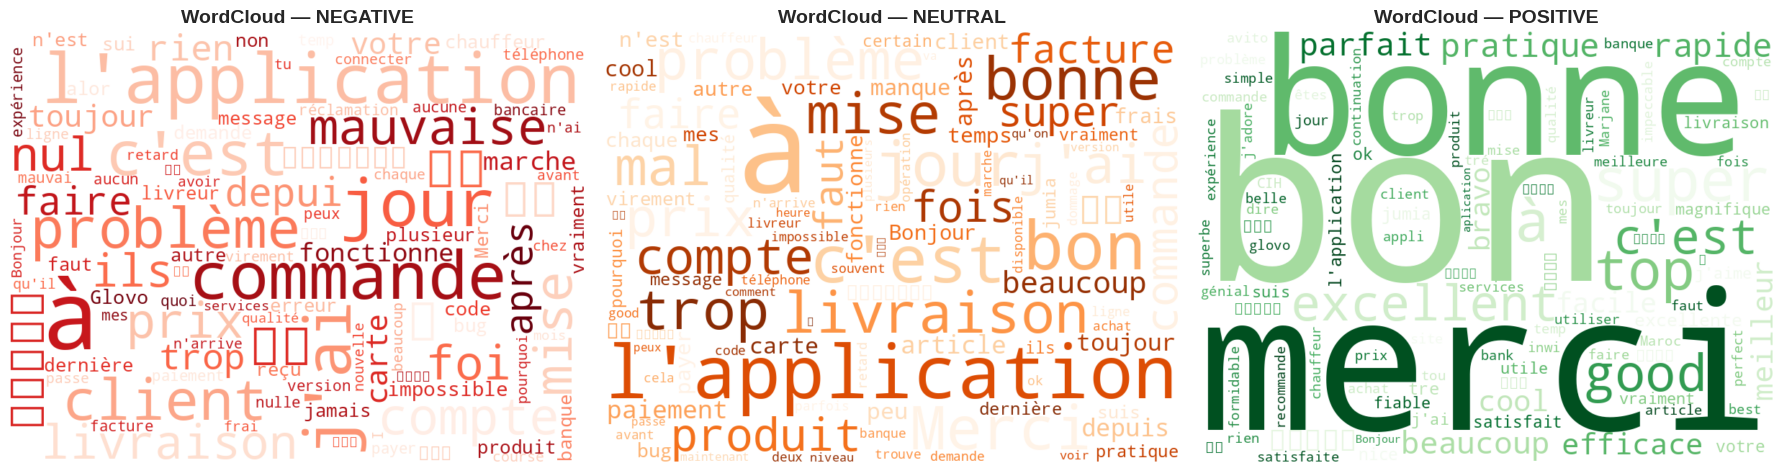

In [10]:
# ═══════════════════════════════════════════════════════
# WORDCLOUDS PAR SENTIMENT
# ═══════════════════════════════════════════════════════

# Stopwords français de base
STOPWORDS_FR = set([
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en', 'est',
    'que', 'qui', 'dans', 'pour', 'pas', 'ne', 'ce', 'il', 'je', 'se',
    'sur', 'au', 'avec', 'son', 'sa', 'ses', 'mais', 'on', 'par', 'plus',
    'cette', 'tout', 'elle', 'mon', 'bien', 'très', 'me', 'ma', 'vous',
    'nous', 'leur', 'même', 'été', 'ont', 'être', 'fait', 'comme', 'sont',
    'peut', 'aussi', 'y', 'a', 'ai', 'j', 'l', 'd', 'n', 's', 'c',
    'qu', 'si', 'ou', 'car', 'ni', 'the', 'and', 'to', 'is', 'app',
    'application', 'cette', 'aux', 'quand', 'puis', 'sans', 'encore',
    'ça', 'ca', 'moi', 'lui', 'te', 'ta', 'ton', 'nos', 'service','vos'
])

sentiments = df[COL_SENTIMENT].unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(6*len(sentiments), 6))

if len(sentiments) == 1:
    axes = [axes]

wc_colors = {
    'positif': 'Greens', 'positive': 'Greens',
    'négatif': 'Reds', 'negatif': 'Reds', 'negative': 'Reds',
    'neutre': 'Oranges', 'neutral': 'Oranges'
}

for ax, sent in zip(axes, sentiments):
    texte = ' '.join(df[df[COL_SENTIMENT] == sent][COL_TEXTE].astype(str).tolist())
    wc = WordCloud(
        width=800, height=600,
        max_words=100,
        background_color='white',
        colormap=wc_colors.get(sent, 'Blues'),
        stopwords=STOPWORDS_FR,
        collocations=False
    ).generate(texte)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'WordCloud — {sent.upper()}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wordclouds_sentiments.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Top 20 Mots par Sentiment

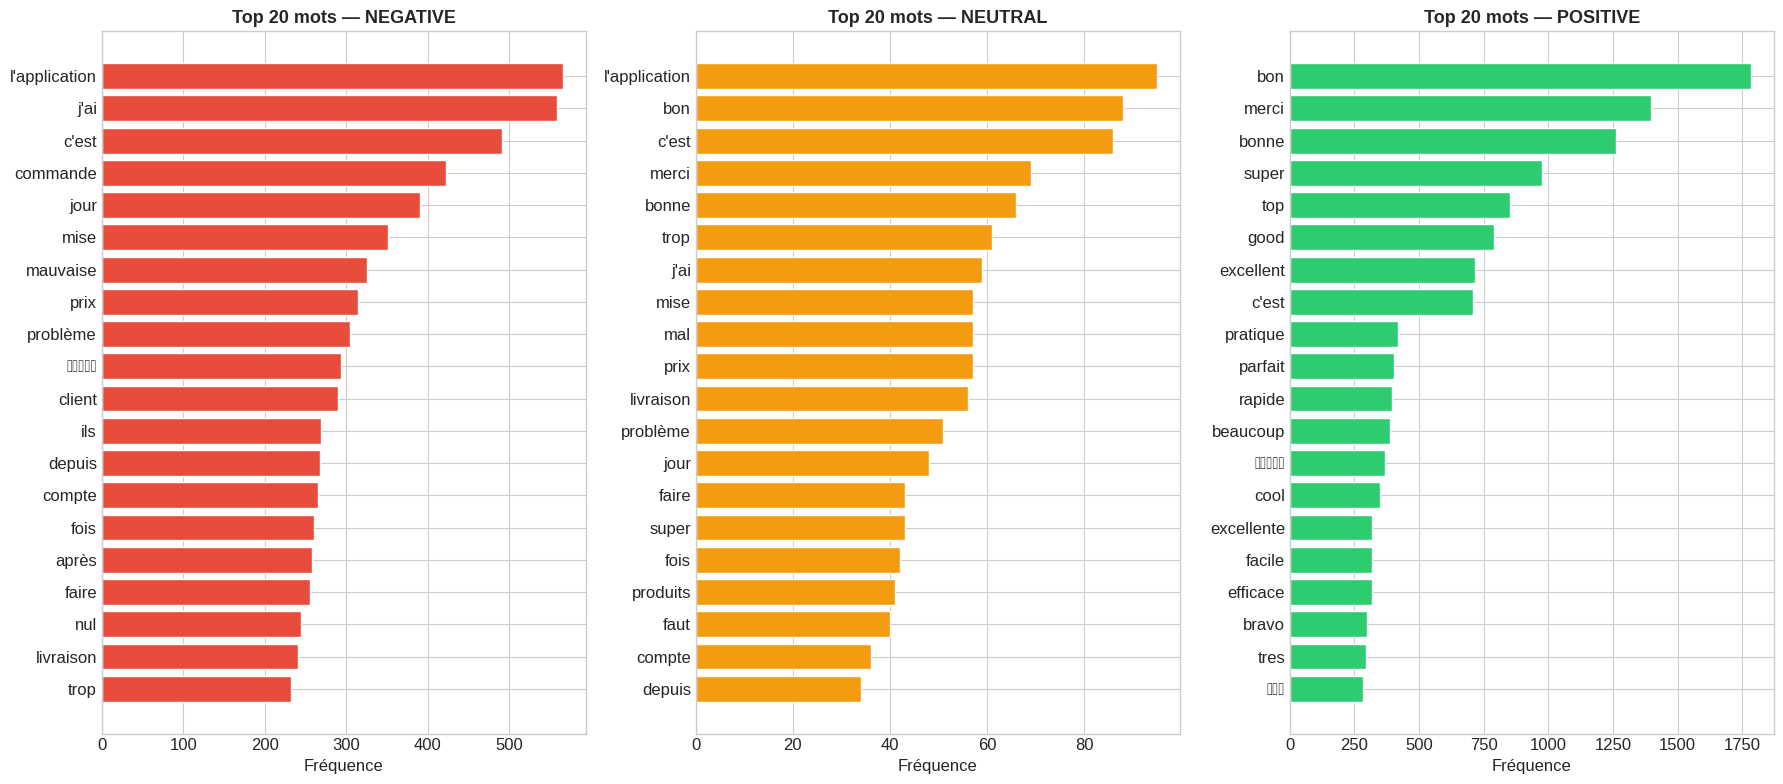

In [11]:
# ═══════════════════════════════════════════════════════
# TOP 20 MOTS LES PLUS FRÉQUENTS PAR SENTIMENT
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(sentiments), figsize=(6*len(sentiments), 8))

if len(sentiments) == 1:
    axes = [axes]

for ax, sent in zip(axes, sentiments):
    texte = ' '.join(df[df[COL_SENTIMENT] == sent][COL_TEXTE].astype(str).str.lower().tolist())
    mots = [m for m in texte.split() if m not in STOPWORDS_FR and len(m) > 2]
    top20 = Counter(mots).most_common(20)

    mots_list = [m[0] for m in top20][::-1]
    counts    = [m[1] for m in top20][::-1]

    ax.barh(mots_list, counts, color=colors.get(sent, '#3498db'), edgecolor='white')
    ax.set_title(f'Top 20 mots — {sent.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top20_mots_par_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Analyse Temporelle

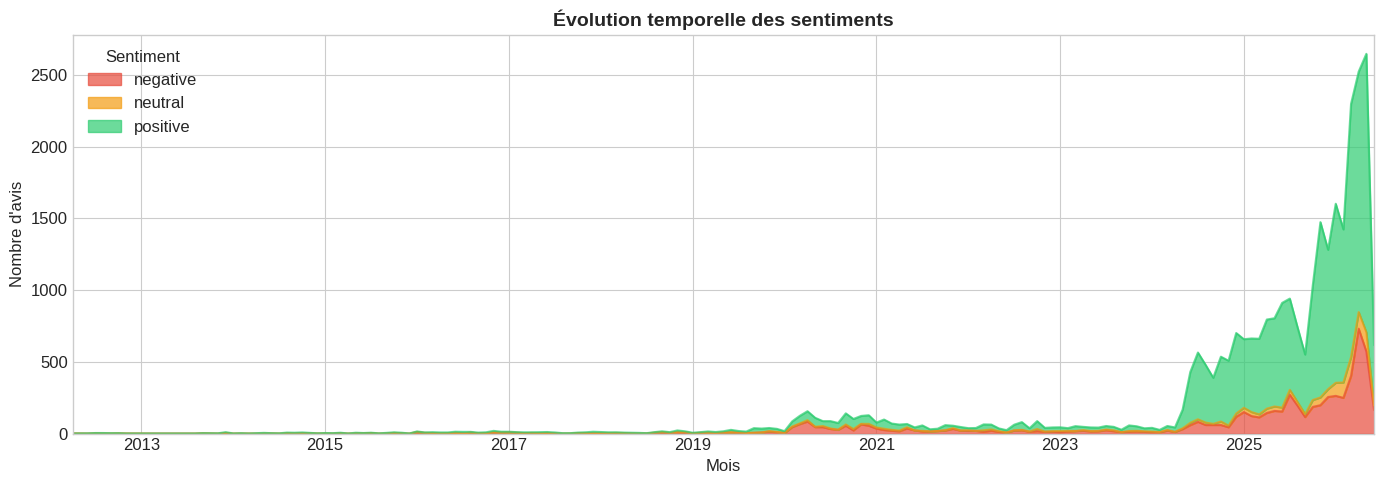

In [12]:
# ═══════════════════════════════════════════════════════
# ANALYSE TEMPORELLE
# ═══════════════════════════════════════════════════════
COL_DATE = 'date_avis'

if COL_DATE in df.columns:
    df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce')
    df_date = df.dropna(subset=[COL_DATE]).copy()
    df_date['mois'] = df_date[COL_DATE].dt.to_period('M')

    fig, ax = plt.subplots(figsize=(14, 5))
    temporal = df_date.groupby(['mois', COL_SENTIMENT]).size().unstack(fill_value=0)
    temporal.plot(kind='area', stacked=True, ax=ax, alpha=0.7,
                 color=[colors.get(c, '#3498db') for c in temporal.columns])
    ax.set_title('Évolution temporelle des sentiments', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Nombre d\'avis')
    ax.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'evolution_temporelle.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 10. Résumé & Observations Clés

In [13]:
# ═══════════════════════════════════════════════════════
# RÉSUMÉ DE L'EDA
# ═══════════════════════════════════════════════════════
print("="*60)
print(" RÉSUMÉ DE L'ANALYSE EXPLORATOIRE")
print("="*60)

print(f"""
 DATASET
   • {len(df):,} avis au total
   • {df[COL_APP].nunique()} applications, {df[COL_CATEGORIE].nunique()} catégories
   • {n_doublons} doublons détectés ({100*n_doublons/len(df):.1f}%)

 DÉSÉQUILIBRE DES CLASSES""")
for sent in sentiment_counts.index:
    print(f"   • {sent:10s} : {sentiment_counts[sent]:>6,} ({100*sentiment_counts[sent]/len(df):5.1f}%)")

print(f"""
 LONGUEUR DES TEXTES
   • Moyenne : {df['nb_mots'].mean():.0f} mots
   • Médiane : {df['nb_mots'].median():.0f} mots
   • P95     : {df['nb_mots'].quantile(0.95):.0f} mots
   → max_len=128 tokens {' suffisant' if df['nb_mots'].quantile(0.95) < 100 else '⚠️ à ajuster'}

🔑 OBSERVATIONS CLÉS
   1. Dataset déséquilibré → utiliser class_weight ou WeightedRandomSampler
   2. {'Beaucoup de textes courts (<3 mots) → à filtrer au preprocessing' if n_courts > 100 else 'Peu de textes très courts → bon signe'}
   3. Vérifier les doublons au preprocessing
   4. Les wordclouds montrent des patterns clairs par sentiment
""")

print("✅ EDA terminée")

 RÉSUMÉ DE L'ANALYSE EXPLORATOIRE

 DATASET
   • 29,405 avis au total
   • 11 applications, 9 catégories
   • 9067 doublons détectés (30.8%)

 DÉSÉQUILIBRE DES CLASSES
   • positive   : 21,523 ( 73.2%)
   • negative   :  6,422 ( 21.8%)
   • neutral    :  1,460 (  5.0%)

 LONGUEUR DES TEXTES
   • Moyenne : 8 mots
   • Médiane : 2 mots
   • P95     : 34 mots
   → max_len=128 tokens  suffisant

🔑 OBSERVATIONS CLÉS
   1. Dataset déséquilibré → utiliser class_weight ou WeightedRandomSampler
   2. Beaucoup de textes courts (<3 mots) → à filtrer au preprocessing
   3. Vérifier les doublons au preprocessing
   4. Les wordclouds montrent des patterns clairs par sentiment

✅ EDA terminée
